# Blackjack Monte Carlo Workshop

Welcome. This notebook is designed for students who are brand new to Reinforcement Learning (RL).

You will implement three functions:
- `first_visit_mc_state_values`
- `first_visit_mc_action_values`
- `mc_control_exploring_starts`

All blackjack game logic and plotting helpers are provided in `blackjack_env.py`.

## Quick Blackjack Refresher

- Goal: finish with a hand value closer to 21 than the dealer, without going over 21.
- Card values: number cards are face value, face cards are 10, Ace is 1 or 11.
- **Usable ace** means an Ace currently counted as 11 that can drop to 1 if needed to avoid busting.
- Player actions in this workshop: `HIT` (take a card) or `STICK` (stop taking cards).
- Dealer rule (fixed): dealer keeps hitting until total is at least 17.
- Rewards at end of each round:
  - `1.0` win
  - `0.5` draw
  - `0.0` loss

## RL in 2 Minutes

In RL, an agent learns by trial and error.

- **State (`s`)**: what situation we are in.
  For this workshop, state uses shape `(10,10,2)`:
  - player sum index `1..10` means sums `12..21`
  - dealer showing card `1..10`
  - usable ace index `1..2` means `{no usable ace, usable ace}`
- **Action (`a`)**: what we do next.
  - `STICK = 1`
  - `HIT = 2`
- **Reward (`r`)**: feedback after an episode ends.
  - `1.0` win, `0.5` draw, `0.0` loss
- **Policy (`pi`)**: a rule that picks an action given a state.
- **Episode**: one full blackjack round.

## What You Will Implement

1. `first_visit_mc_state_values(policy, ...)`
   - Estimate **V(s)** under a fixed policy by averaging first-visit returns for each state.

2. `first_visit_mc_action_values(policy, ...)`
   - Estimate **Q(s,a)** under a fixed policy by averaging first-visit returns for each state-action pair.

3. `mc_control_exploring_starts(...)`
   - Learn a near-optimal policy by alternating:
     - generate episode from random start state/action,
     - first-visit Q update,
     - greedy policy improvement.

## Colab Setup (Optional)

If you open this notebook in Google Colab, set your GitHub repo URL in the next cell.
It will clone the repo and make `blackjack_env.py` importable.

If you run locally, this cell does nothing.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/evcoats/rl_workshop_blackjack.git"
REPO_BRANCH = "main"
COLAB_DIR = Path("/content/rl_workshop_blackjack")

def _in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

if _in_colab():
    if "<your-user>" in REPO_URL or "<your-repo>" in REPO_URL:
        print("Set REPO_URL in this cell, then re-run it.")
    else:
        if not (COLAB_DIR / "blackjack_env.py").exists():
            subprocess.run(
                [
                    "git",
                    "clone",
                    "--depth",
                    "1",
                    "--branch",
                    REPO_BRANCH,
                    REPO_URL,
                    str(COLAB_DIR),
                ],
                check=True,
            )
        os.chdir(COLAB_DIR)
        if str(COLAB_DIR) not in sys.path:
            sys.path.insert(0, str(COLAB_DIR))
        print(f"Working directory: {Path.cwd()}")
        print("Colab setup complete.")
else:
    print("Local run detected. Colab clone step skipped.")

Working directory: /content/rl_workshop_blackjack
Colab setup complete.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Workshop convenience import (keeps the notebook uncluttered)
from blackjack_env import *

## Thorp (1966) One-Deck Reference Policy (Beginning)

We compare against a Thorp-style one-deck hit/stand policy as a **mostly-optimal historical baseline**.

Reference source:
- `Beat the Dealer` (Edward O. Thorp, 1966)

This workshop environment uses only `HIT`/`STICK` actions (no split/double/surrender).

Thorp source: Edward O. Thorp, Beat the Dealer (1966)


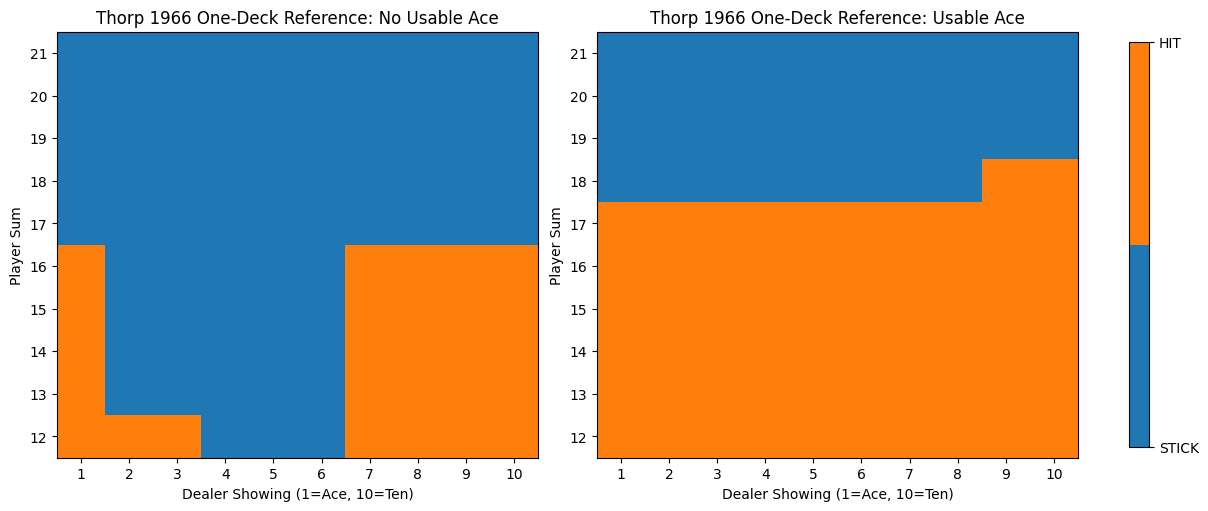

In [3]:
reference_policy = make_thorp_1966_policy()
print("Thorp source:", THORP_1966_BOOK)
fig, _ = plot_policy_two_charts(reference_policy, title_prefix="Thorp 1966 One-Deck Reference")
plt.show()

## Quick Baseline Check: Thorp as a Strong Reference

This quick chart compares Thorp's one-deck policy against simple threshold policies.

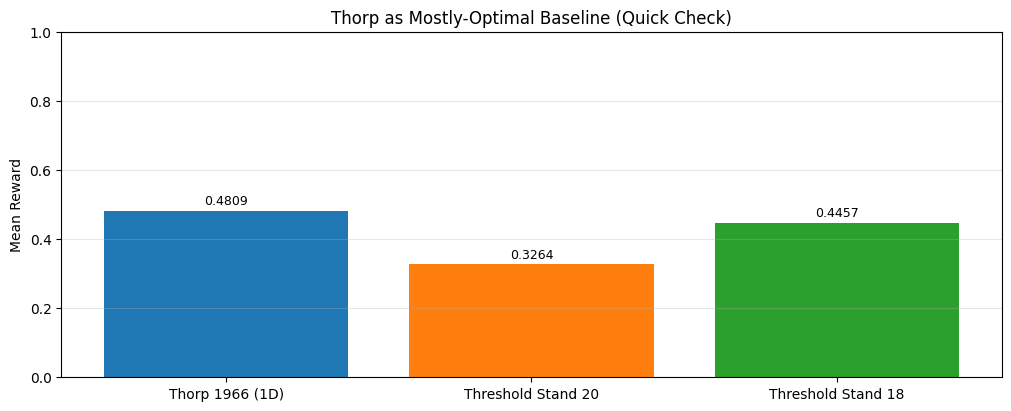

{'Thorp 1966 (1D)': 0.480875, 'Threshold Stand 20': 0.326375, 'Threshold Stand 18': 0.44575}


In [4]:
quick_scores, quick_fig, _ = evaluate_and_plot(
    {
        "Thorp 1966 (1D)": reference_policy,
        "Threshold Stand 20": make_threshold_policy(20),
        "Threshold Stand 18": make_threshold_policy(18),
    },
    n_episodes=8_000,
    seed=101,
    title="Thorp as Mostly-Optimal Baseline (Quick Check)",
)
plt.show()
print(quick_scores)

## Function 1: First-Visit MC State Values `V(s)`

If you are new to RL, think of `V(s)` as:
- "How good is this state on average if I follow this policy from here?"

In this blackjack setup:
- A **state** is `(player_sum_idx, dealer_showing, usable_ace_idx)`.
- The episode ends with one reward (`1.0`, `0.5`, or `0.0`).

What this function should do:
1. Run many episodes using the given policy.
2. In each episode, only count the **first time** each state appears.
3. For that first visit, add the final episode reward to that state's running total.
4. Return the average reward per state.

Why first-visit?
- It avoids over-counting repeated visits to the same state in one episode.

Inputs:
- `policy`, `n_episodes`, `seed`

Returns:
- `values` with shape `(10,10,2)`
- `visit_counts` with shape `(10,10,2)`

In [18]:
def first_visit_mc_state_values(policy, n_episodes=100_000, seed=0):
    rng = np.random.default_rng(seed)
    returns_sum = np.zeros((10, 10, 2), dtype=np.float64)
    visit_counts = np.zeros((10, 10, 2), dtype=np.int64)

    # YOUR CODE HERE
    # 1) Generate episodes with generate_episode(policy, rng)
    # 2) For each episode, only update each state once (first-visit)
    # 3) Add final reward to returns_sum and increment visit_counts
    for i in range(n_episodes):
      score, states, actions = generate_episode(policy, rng)
      visited_this_episode = set()
      for state in states:
        if state not in visited_this_episode:
          idx = state_to_indices(state)
          returns_sum[idx] += score
          visit_counts[idx] += 1

          visited_this_episode.add(state)

    values = np.divide(
        returns_sum,
        visit_counts,
        out=np.zeros_like(returns_sum),
        where=visit_counts > 0,
    )
    return values, visit_counts

## Function 2: First-Visit MC Action Values `Q(s,a)`

`Q(s,a)` means:
- "How good is it, on average, to take action `a` in state `s`, then continue with the policy?"

Difference from Function 1:
- Function 1 rates states only.
- Function 2 rates **state + action** pairs.

What this function should do:
1. Run many episodes under the given policy.
2. Track pairs `(state, action)` seen in that episode.
3. Only update the **first visit** of each `(state, action)` pair.
4. Add final reward to that pair's running return total.
5. Average to produce `Q`.

Shape details:
- `Q` shape is `(10,10,2,2)`.
- Last axis is action index:
  - index `0` = `STICK`
  - index `1` = `HIT`

Returns:
- `q_values` and `visit_counts`, both shape `(10,10,2,2)`

In [21]:
def first_visit_mc_action_values(policy, n_episodes=100_000, seed=0):
    rng = np.random.default_rng(seed)
    returns_sum = np.zeros((10, 10, 2, 2), dtype=np.float64)
    visit_counts = np.zeros((10, 10, 2, 2), dtype=np.int64)

    # YOUR CODE HERE
    # 1) Generate episodes with generate_episode(policy, rng)
    # 2) Track first-visit (state, action) pairs per episode
    # 3) Update returns_sum[..., action_index] and visit_counts
    for i in range(n_episodes):
      score, states, actions = generate_episode(policy, rng)
      visited_this_episode = set()
      for state,action in zip(states,actions):
        if (state,action-1) not in visited_this_episode:
          idx = state_to_indices(state)
          new_idx = idx + (action-1,)
          returns_sum[new_idx] += score
          visit_counts[new_idx] += 1

          visited_this_episode.add(new_idx)

    q_values = np.divide(
        returns_sum,
        visit_counts,
        out=np.zeros_like(returns_sum),
        where=visit_counts > 0,
    )
    return q_values, visit_counts

## Function 3: MC Control with Exploring Starts

Goal:
- Learn a strong policy automatically, instead of fixing policy by hand.

Core idea:
- Alternate between:
  1. **Evaluation**: estimate `Q(s,a)` from sampled episodes.
  2. **Improvement**: make policy greedy w.r.t. current `Q`.

What "exploring starts" means:
- Every episode starts from a random state and a random first action.
- This ensures broad exploration so the algorithm learns many state-action values.

What this function should do each episode:
1. Sample random `start_state` and random `start_action`.
2. Generate one episode using current policy after that first action.
3. First-visit update of `Q(s,a)` for visited pairs.
4. For visited states, set policy to greedy action:
   - choose `STICK` if `Q(stick) >= Q(hit)`
   - else choose `HIT`

Returns:
- `policy` (learned)
- `q_values`
- `visit_counts`

Interpretation:
- After many episodes (e.g., 100,000), policy should approach a near-optimal blackjack strategy for this environment.

### Visual Intuition For Function 3
![MC control unfolding](https://github.com/evcoats/rl_workshop_blackjack/blob/main/mc_control_unfolding.png?raw=1)
![MC control loop](https://github.com/evcoats/rl_workshop_blackjack/blob/main/mc_control_loop.png?raw=1)

In [28]:
def mc_control_exploring_starts(n_episodes=100_000, seed=0):
    rng = np.random.default_rng(seed)
    policy = rng.choice([STICK, HIT], size=(10, 10, 2)).astype(np.int8)
    q_values = np.zeros((10, 10, 2, 2), dtype=np.float64)
    visit_counts = np.zeros((10, 10, 2, 2), dtype=np.int64)

    # YOUR CODE HERE
    # Per episode:
    # 1) sample start_state and start_action (exploring starts)
    # 2) generate episode following current policy after first action
    # 3) first-visit update for Q(s,a)
    # 4) greedy policy improvement on visited states

    # sum of all scores for each pair
    returns_sum = np.zeros((10, 10, 2, 2), dtype=np.float64)

    for i in range(n_episodes):
      start_state = random_start_state(rng)
      start_action = rng.integers(1,3)
      score, states, actions = generate_episode(policy,rng,start_state,start_action)
      visited_this_episode = set()
      for state,action in zip(states,actions):
        full_idx = state_to_indices(state) + (action-1,)
        if full_idx not in visited_this_episode:
          visit_counts[full_idx]+=1
          returns_sum[full_idx] += score
          q_values[full_idx] = returns_sum[full_idx] / visit_counts[full_idx]
          policy[state_to_indices(state)] = np.argmax(q_values[state_to_indices(state)])+1
          visited_this_episode.add(full_idx)




    return policy, q_values, visit_counts

## Run After Completing The 3 Functions

In [33]:
# Run this after you implement the 3 TODO functions above.
baseline = make_threshold_policy(20)
V, V_counts = first_visit_mc_state_values(baseline, n_episodes=500000, seed=1)
Q, Q_counts = first_visit_mc_action_values(baseline, n_episodes=500000, seed=1)
learned_policy, learned_Q, learned_counts = mc_control_exploring_starts(n_episodes=500000, seed=1)

print("Baseline mean reward:", round(evaluate_policy(baseline, n_episodes=100_000, seed=7), 4))
print("Learned mean reward:", round(evaluate_policy(learned_policy, n_episodes=100_000, seed=7), 4))

Baseline mean reward: 0.3254
Learned mean reward: 0.4762


## Evaluate Thorp (1966) vs MC-Control (100,000 episodes)

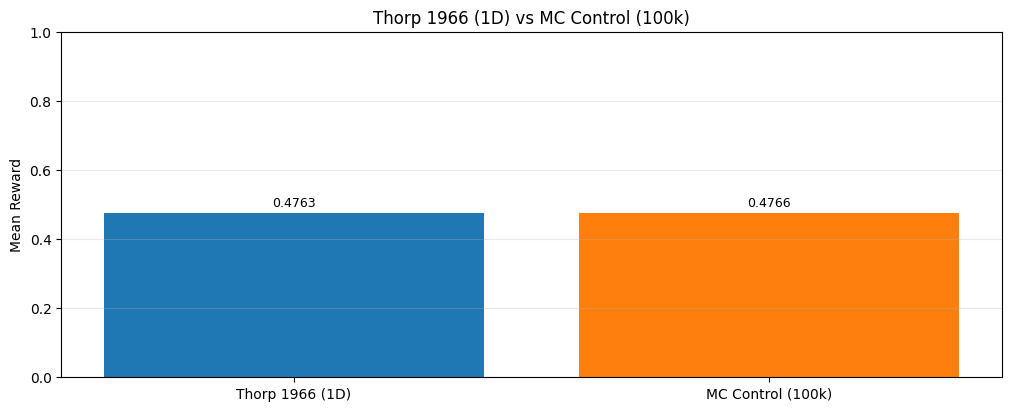

{'Thorp 1966 (1D)': 0.476327, 'MC Control (100k)': 0.476579}


In [34]:
# Uncomment after learned_policy is available.
report, fig, ax = thorp_report(
    learned_policy,
    n_episodes=500000,
    seed=42,
    policy_label="MC Control (100k)",
    top_k_mismatches=10,
)
plt.show()
print(report["scores"])

## Final Target Check (End)

Compare learned policy visually and numerically to the Thorp (1966) one-deck reference policy.

### Sutton-Style Optimal Policy Target (Reference Image)
![Sutton optimal policy target](https://github.com/evcoats/rl_workshop_blackjack/blob/main/optimal_blackjack_policy.png?raw=1)

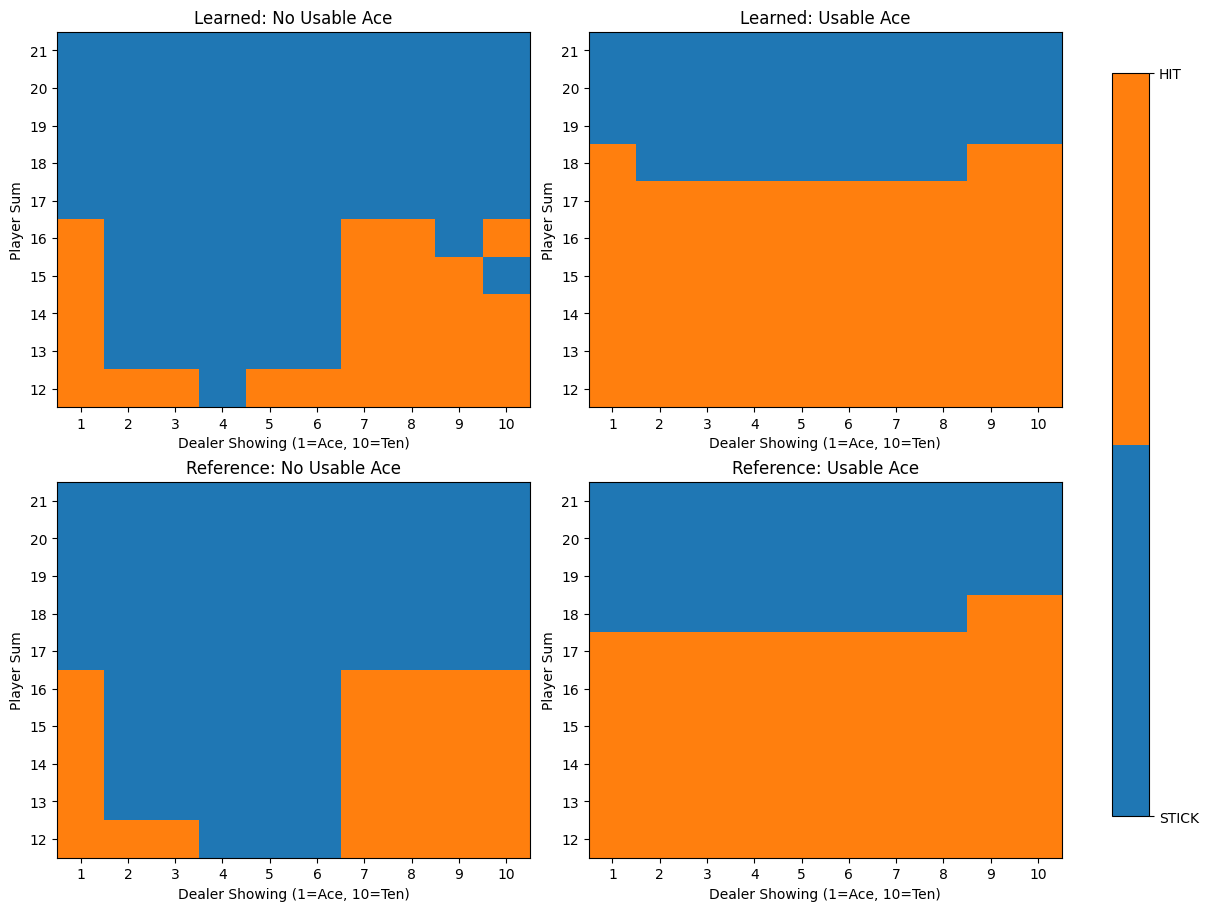

Agreement overall: 0.975
Agreement (no usable ace): 0.96
Agreement (usable ace): 0.99
Mismatch states: 5 out of 200
Mismatch examples:
{'player_sum': 12, 'dealer_up': 5, 'usable_ace': False, 'thorp_action': 'STICK', 'learned_action': 'HIT'}
{'player_sum': 12, 'dealer_up': 6, 'usable_ace': False, 'thorp_action': 'STICK', 'learned_action': 'HIT'}
{'player_sum': 15, 'dealer_up': 10, 'usable_ace': False, 'thorp_action': 'HIT', 'learned_action': 'STICK'}
{'player_sum': 16, 'dealer_up': 9, 'usable_ace': False, 'thorp_action': 'HIT', 'learned_action': 'STICK'}
{'player_sum': 18, 'dealer_up': 1, 'usable_ace': True, 'thorp_action': 'STICK', 'learned_action': 'HIT'}


In [35]:
# Uncomment after learned_policy is available.
fig, _ = plot_policy_comparison(learned_policy, reference_policy)
plt.show()

print("Agreement overall:", round(report["agreement_overall"], 4))
print("Agreement (no usable ace):", round(report["agreement_no_usable_ace"], 4))
print("Agreement (usable ace):", round(report["agreement_usable_ace"], 4))
print("Mismatch states:", report["mismatch_states"], "out of", report["total_states"])
print("Mismatch examples:")
for row in report["mismatch_examples"]:
    print(row)